# Preparation

In [1]:
!pip install basicsr
!pip install super-image
!pip install torch
!pip install torchvision
!pip install scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 13.6 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214817 sha256=bbc5cb6f3227dee94c9433b49fdddf5ae07065d3336a61461eb5a24a6e1dd54c
  Stored in directory: /root/.cache/pip/wheels/9a/e3/e4/58f29bfabb622dd40b6d9839318ce5bf092062b81ca3aa19ea
Successfully built basicsr
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 7.5 MB/s eta 0:00:00


In [2]:
from super_image import EdsrModel, ImageLoader
import requests
from PIL import Image
from io import BytesIO
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np

In [3]:
import glob
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
device

'cuda'

In [ ]:
#DATA_PATH = "/gdrive/MyDrive/Super_Resolution/Data/Test_images_2023"
#DATA_PATH = "/gdrive/MyDrive/SR_seeds/Test_images_2023"
DATA_PATH = "/gdrive/MyDrive/SR_seeds/Grains_(Pasynkov)"

In [ ]:
all_orig_imgs = []
all_lr_imgs = []
for i in range(2651, 4501):
  img = Image.open(DATA_PATH + f"/grain_{i}.png").convert("RGB")

  all_orig_imgs.append(img)

  w, h = img.size

  lr_img = img.resize((int(w*1), int(h*1)))
  all_lr_imgs.append(lr_img)

In [6]:
transform = T.ToTensor()
to_pil = T.ToPILImage()

In [7]:
all_sr_imgs = []

# EDSR

In [8]:
model = EdsrModel.from_pretrained('eugenesiow/edsr', scale=4).to(device)
model.eval()

SAVE_PATH = "/gdrive/MyDrive/SR_seeds/EDSR_(Pasynkov)/"
import os
os.makedirs(SAVE_PATH, exist_ok=True)
i = 2650

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

pytorch_model_4x.pt:   0%|          | 0.00/172M [00:00<?, ?B/s]

https://huggingface.co/eugenesiow/edsr/resolve/main/pytorch_model_4x.pt


In [ ]:
for img in all_lr_imgs:
    i += 1
    inputs = ImageLoader.load_image(img).to(device)

    with torch.no_grad():
        preds = model(inputs)

    preds = preds.squeeze(0).cpu()

    sr_img = to_pil(preds)
    all_sr_imgs.append(sr_img)

    filename = f"{str(i).zfill(4)}.png"  # 0001.png, 0002.png ...
    sr_img.save(os.path.join(SAVE_PATH, filename))

https://huggingface.co/eugenesiow/edsr/resolve/main/pytorch_model_4x.pt


# Evaluation

In [9]:
LR_PATH = "/gdrive/MyDrive/SR_seeds/Evaluation/LR/"
HR_PATH = "/gdrive/MyDrive/SR_seeds/Evaluation/HR/"

In [10]:
all_lr_imgs = []
all_hr_imgs = []

In [11]:
for i in range(1, 8):
    lr_img = Image.open(os.path.join(LR_PATH, f"lr_img_{i}.png")).convert("RGB")
    hr_img = Image.open(os.path.join(HR_PATH, f"hr_img_{i}.png")).convert("RGB")

    all_lr_imgs.append(lr_img)
    all_hr_imgs.append(hr_img)

In [12]:
import torch.nn.functional as F
from math import log10
from skimage.metrics import structural_similarity as ssim
import numpy as np

psnr_list = []
ssim_list = []

In [13]:
def compute_psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 10 * log10(1.0 / mse.item())


def compute_ssim(sr, hr):
    sr = sr.permute(1, 2, 0).cpu().numpy()
    hr = hr.permute(1, 2, 0).cpu().numpy()

    return ssim(sr, hr, channel_axis=2, data_range=1.0)

In [14]:
sr_results = []

In [15]:
def match_size(sr, hr):
    """
    HR to the size of SR through bilinear resize
    """
    sr_h, sr_w = sr.shape[-2], sr.shape[-1]
    hr = F.interpolate(hr.unsqueeze(0), size=(sr_h, sr_w), mode="bilinear", align_corners=False)
    return hr.squeeze(0)

In [16]:
for i, (lr_img, hr_img) in enumerate(zip(all_lr_imgs, all_hr_imgs)):

    # ===== SR inference =====
    lr_gray = lr_img.convert("RGB")

    w, h = lr_gray.size
    upscaled = lr_gray.resize((w*4, h*4))

    inp = transform(upscaled).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(inp)

    sr_tensor = out.squeeze(0).cpu().clamp(0, 1)

    sr_img = to_pil(sr_tensor)

    sr_results.append(sr_img)

    # ===== HR tensor =====
    hr_tensor = T.ToTensor()(hr_img.convert("RGB"))

    # ===== ALIGN SIZE (КРИТИЧНО) =====
    if hr_tensor.shape != sr_tensor.shape:
        hr_tensor = match_size(sr_tensor, hr_tensor)

    # ===== METRICS =====
    psnr_val = compute_psnr(sr_tensor, hr_tensor)
    ssim_val = compute_ssim(sr_tensor, hr_tensor)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

    print(f"[{i+1}] PSNR: {psnr_val:.3f} | SSIM: {ssim_val:.4f}")

[1] PSNR: 35.018 | SSIM: 0.9190
[2] PSNR: 34.642 | SSIM: 0.8752
[3] PSNR: 35.844 | SSIM: 0.9116
[4] PSNR: 34.842 | SSIM: 0.8726
[5] PSNR: 34.063 | SSIM: 0.8809
[6] PSNR: 35.359 | SSIM: 0.8949
[7] PSNR: 34.062 | SSIM: 0.8822


In [18]:
print("\n========== FINAL ==========")
print(f"Mean PSNR: {np.mean(psnr_list):.3f}")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")


========== FINAL ==========
Mean PSNR: 34.833
Mean SSIM: 0.8909


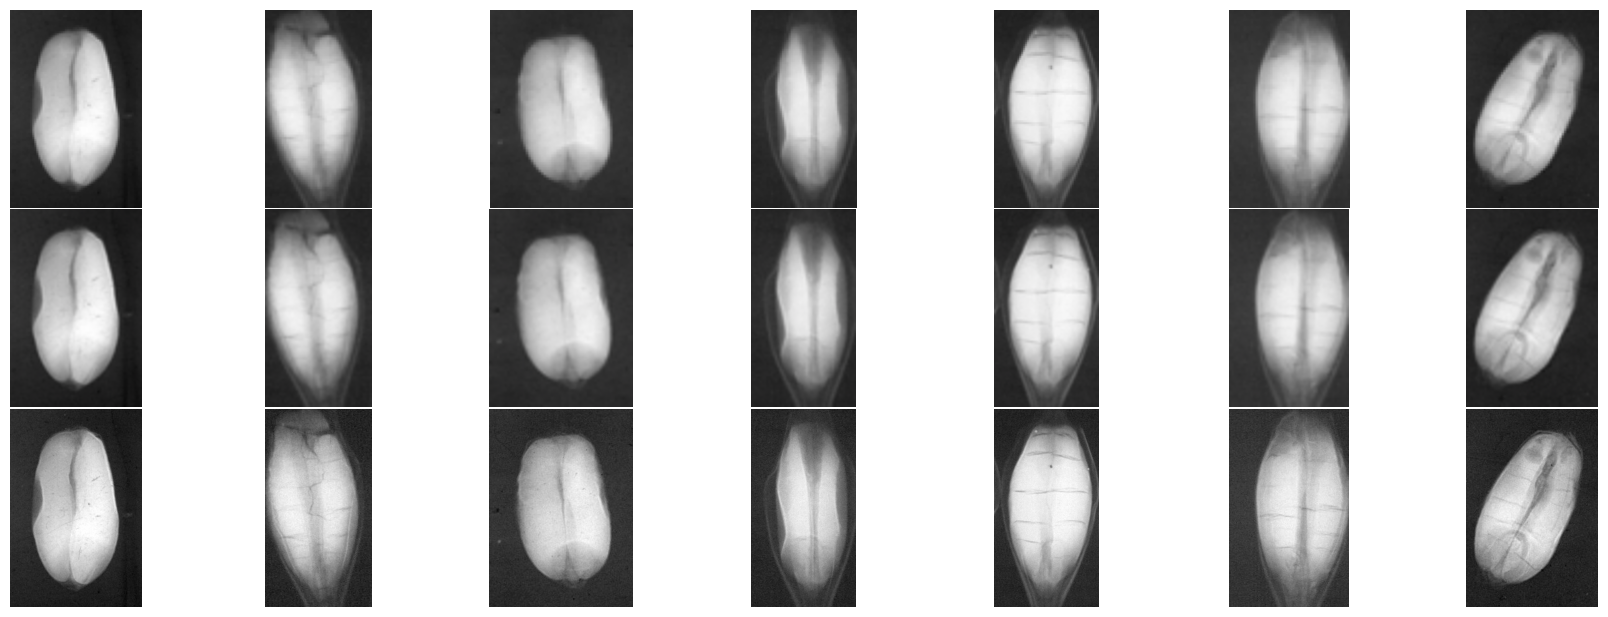

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 7, figsize=(18, 6))

plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i in range(7):

    # ===== LR =====
    axes[0, i].imshow(all_lr_imgs[i])
    axes[0, i].axis("off")

    # ===== SR =====
    axes[1, i].imshow(sr_results[i].resize(all_hr_imgs[i].size), cmap="gray")
    axes[1, i].axis("off")

    # ===== HR =====
    axes[2, i].imshow(all_hr_imgs[i])
    axes[2, i].axis("off")

plt.tight_layout(pad=0.1)
plt.show()
